# Modul 6 Inversi
## Muhammad Nabil Abhyasa // 123120071

### Permasalahan 1
Aplikasi Grid Search dan Simulated Annealing pada penentuan Hiposenter Gempa pada medium 2D

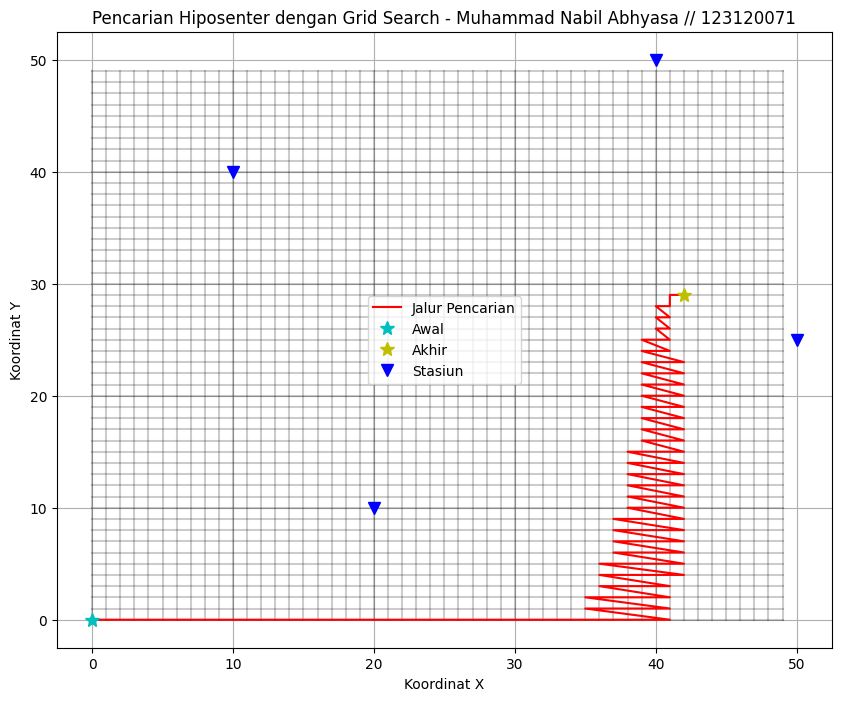

Koordinat X Hiposenter : 42
Koordinat Y Hiposenter : 29
Nilai Misfit Minimum   : 0.3892487158369358
Jumlah Iterasi: 176


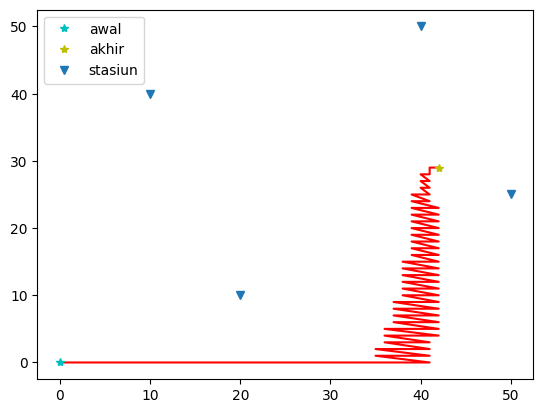

Text(0.5, 1.0, 'kurva RMS VS N Iterasi')

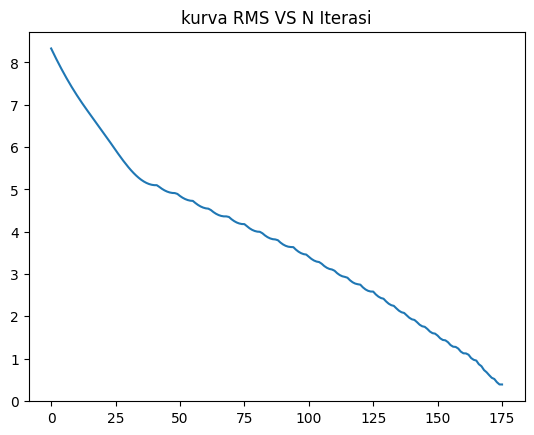

In [ ]:
# Grid Search
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv

Vavg = 4                                                # kecepatan rata-rata gelombang P           
tobs = [7.1,1.8,5.0, 7.9]                               # Waktu tiba gelombang P 
tobs = np.reshape (tobs, (len (tobs) , 1) )             # Mengubah list tobs menjadi array NumPy berbentuk matriks kolom 
Xsts = [20, 50, 40, 10]                                 # Koordinat X (horizontal) dari keempat stasiun seismik.
Ysts = [10,25,50,40]                                    # Koordinat Y (vertikal) dari keempat stasiun seismik.

# Definisikan ruang model
L = 1 #Lebar Grid
X0 = np.arange (0,50,L)                                 # Membuat array koordinat X dari 0 hingga 49
Y0 = np.arange (0,50,L)                                 # Membuat array koordinat Y dari 0 hingga 49         

# Lakukan looping pencarian model solusi yang menghasilkan misfit minimum
P = 10 # nilai aval taksiran misfit minimum (dalam sekon)
HypoX = []                                              # List kosong untuk menyimpan koordinat X 
HypoY = []                                              # List kosong untuk menyimpan koordinat Y
erms  = []                                              # List kosong untuk menyimpan nilai RMS 

for i in range (len (Y0) ) :                                                       # Looping luar untuk setiap nilai koordinat Y pada grid.
    for j in range (len (X0) ) :                                                   # Looping tengah untuk setiap nilai koordinat X pada grid.
        # tcal = [] 
        Dt = []                                                                    
        for k in range (len (Xsts) ) :                                             # # Looping dalam untuk setiap stasiun seismik (k = 0 sampai 3)
            tcal=(np.sqrt ((X0[j]-Xsts[k]) ** 2+(Y0[i]-Ysts[k]) ** 2) /Vavg)       # Menghitung waktu tempuh teoritis (tcal) dari titik grid (X0[j], Y0[i]) ke stasiun ke-k
            Dt.append ((tobs [k]-tcal) ** 2)                                       # Menghitung selisih kuadrat antara waktu observasi (tobs[k]) dan waktu kalkulasi (tcal) untuk stasiun ke-k, lalu menambahkannya ke list Dt

        misfit = np.sqrt (np.mean (Dt) )                                           # Menghitung nilai RMS (Root Mean Square) error dari semua selisih kuadrat yang tersimpan di Dt
        if misfit < P:                                                             # Jika misfit pada titik grid saat ini lebih kecil dari nilai misfit minimum yang tersimpan
            HypoX. append (X0[j])                                                  # Simpan koordinat X titik grid ini.
            HypoY. append (Y0[i])                                                  # Simpan koordinat Y titik grid ini.
            erms.append(misfit)                                                    # Simpan koordinat X titik grid ini.
            P = misfit                                                             # Perbarui nilai misfit minimum (P) dengan nilai misfit yang baru (lebih kecil.
        else : 
            pass                                                                   # Jika tidak lebih kecil, lewati 

# Plot hasil
plt.figure(figsize=(10, 8))                                                 # Membuat figure/kanvas baru dengan ukuran 10×8 inci.

#Plot Grid
for x in X0:
    plt.plot([x, x], [Y0[0], Y0[-1]], 'k-', alpha=0.2)                      # Menggambar garis vertikal pada setiap koordinat X dengan transparansi 0.1    
for y in Y0:                                                                # Menggambar garis horizontal pada setiap koordinat Y dengan transparansi 0.1    
    plt.plot([X0[0], X0[-1]], [y, y], 'k-', alpha=0.2) 

# Jalur pencarian
plt.plot(HypoX, HypoY, '-r', label='Jalur Pencarian')                       # Menggambar jalur pencarian hiposenter dengan garis merah
plt.plot(HypoX[0], HypoY[0], '*c', markersize=10, label='Awal')             # Menandai posisi awal hiposenter dengan simbol bintang cyan
plt.plot(HypoX[-1], HypoY[-1], '*y', markersize=10, label='Akhir')          # Menandai posisi akhir hiposenter dengan simbol bintang kuning

# Stasiun   
plt.plot(Xsts, Ysts, 'v', markersize=8, color='blue', label='Stasiun')      # Menandai posisi stasiun dengan simbol segitiga terbalik berwarna biru

# Label
plt.xlabel('Koordinat X')                                                                       #Memberikan label pada sumbu X dengan teks "Koordinat X"
plt.ylabel('Koordinat Y')                                                                       #Memberikan label pada sumbu Y dengan teks "Koordinat Y"                                           
plt.title('Pencarian Hiposenter dengan Grid Search - Muhammad Nabil Abhyasa // 123120071')      #Memberikan judul pada plot dengan teks "Pencarian Hiposenter dengan Grid Search - Muhammad Nabil Abhyasa // 123120071"
plt.legend()                                                                                    #Menampilkan legenda pada plot untuk membedakan antara jalur pencarian, posisi awal, posisi akhir, dan stasiun
plt.grid(True)                                                                                  #Menampilkan grid pada plot

plt.show()                                                                                      #Menampilkan plot yang telah dibuat

#Output
# Output Hasil
print('Koordinat X Hiposenter :', HypoX[-1])                                                    #Menampilkan koordinat X hiposenter yang ditemukan pada iterasi terakhir
print('Koordinat Y Hiposenter :', HypoY[-1])                                                    #Menampilkan koordinat Y hiposenter yang ditemukan pada iterasi terakhir                                
print('Nilai Misfit Minimum   :', P)                                                            #Menampilkan nilai misfit minimum yang ditemukan                                
print('Jumlah Iterasi:', len(HypoX)) 

# Hypo = np.array ([HypoX,HypoY])
# print (Hypo)
plt.plot(HypoX, HypoY, '-r')                                                                    # Menggambar ulang jalur pencarian pada figure baru. 
plt.plot(HypoX[0], HypoY[0], '*c', label='awal')                                                # Menandai titik awal (cyan).
plt.plot(HypoX[len(HypoX)-1], HypoY[len(HypoY)-1], '*y', label='akhir')                         # Menandai titik akhir dengan indeks eksplisit (kuning).
plt.plot(Xsts, Ysts, 'v', label='stasiun' )                                                     # Menandai stasiun.                                                   
plt.xlabel('')                                                                                  # Sumbu X dibiarkan tanpa label.
plt.legend()
plt. show()
plt.plot(erms)                                                                                  # Menggambar kurva konvergensi nilai RMS error terhadap jumlah iterasi
plt.title('kurva RMS VS N Iterasi')                                                             # Memberi judul pada kurva konvergensi RMS.

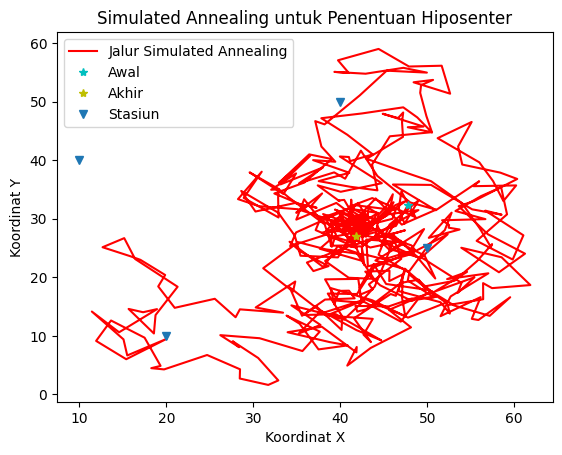

Final Hypocenter: 41.75024228010323 26.97902033963089
Final Misfit: 0.3001790392843325
Iterations: 477


In [ ]:
#Simulated Annealing
import numpy as np
import matplotlib.pyplot as plt

# Data observasi
Vavg = 4                                # Kecepatan rata-rata gelombang dalam medium
tobs = [7.1, 1.8, 5.0, 7.9]             # Waktu tiba gelombang P yang diamati di setiap stasiun
Xsts = [20,50, 40, 10]                  # Koordinat X stasiun
Ysts = [10,25, 50, 40]                  # Koordinat Y stasiun

# Parameter Simulated Annealing
Xmin, Ymin = 0, 0                       # Batas bawah ruang pencarian
Xmax, Ymax = 50, 50                     # Batas atas ruang pencarian
TO = 100                                # Temperatur awal
Tmin = 0.1                              # Temperatur minimum
alpha = 0.99                            # Faktor pendInginan (cooling rate)
max_iter = 1000                         # Maksimum iterasi

# Inisialisasi variabel
X = np.random.uniform(Xmin, Xmax)       # Koordinat X awal (acak)
Y = np.random.uniform(Ymin, Ymax)       # Koordinat Y awal (acak)
HypoX, HypoY = [X], [Y]                 # List untuk menyimpan koordinat hiposenter

# Algoritma Simulated Annealing
T = TO                                                                  # Menginisialisasi temperatur dengan nilai awal 100.
for k in range(max_iter):                                               # Looping utama algoritma sebanyak 1000 iterasi.  
    # Perturbasi solusi saat ini
    dX = np.random.uniform(-1, 1) * (Xmax - Xmin) / 10                  # Menghasilkan nilai perturbasi (gangguan) acak untuk koordinat X dalam rentang [-5, 5].
    dY = np.random.uniform(-1, 1) * (Ymax - Ymin) / 10                  # Menghasilkan nilai perturbasi acak untuk koordinat Y dalam rentang [-5, 5].
    X1 = X + dX                                                         # Menghitung koordinat X kandidat baru (solusi tetangga).
    Y1 = Y + dY                                                         # Menghitung koordinat Y kandidat baru.

    # Hitung misfit untuk solust saat ini dan solusi boru
    E = np.mean([(tobs[i] - np.sqrt((X - Xsts[i]) ** 2 + (Y - Ysts[i]) ** 2) / Vavg) ** 2 for i in range(len(Xsts) ) ])             # Menghitung misfit (energy) untuk solusi saat ini (X, Y). Rumus: rata-rata selisih kuadrat antara waktu observasi dan waktu kalkulasi
    E1 = np.mean([(tobs[i] - np.sqrt((X1 - Xsts[i]) ** 2 + (Y1 - Ysts[i]) ** 2) / Vavg) ** 2 for i in range(len(Xsts) ) ])          # Menghitung misfit untuk solusi kandidat baru (X1, Y1).
    dE = E1 - E                                                                                                                     # Menghitung perbedaan misfit antara solusi baru dan solusi lama.

    # Terima atau tolak solusi baru
    if dE < 0 or np.exp(-dE / T) > np.random.rand():                                                                                # Kondisi penerimaan solusi baru
        X, Y = X1, Y1                                                                                                               # Update posisi hiposenter ke solusi baru yang diterima.
        HypoX. append(X)
        HypoY. append(Y)                                                                                                            # Simpan koordinat yang diterima.

    # Pendinginan (cooling schedule)
    T *= alpha                                                                                                                      # Mengurangi temperatur dengan faktor alpha = 0.99 setiap iterasi. Ini disebut exponential cooling.
    if T < Tmin:                                                                                                                    
        break                                                                                                                       # Jika temperatur sudah di bawah 0.1, hentikan algoritma lebih awal.

# Plot hasil Simulated Annealing
plt.plot(HypoX, HypoY, '-r', label='Jalur Simulated Annealing')                                     # Menggambar jalur pencarian dari titik awal sampai titik akhir dengan garis merah.
plt.plot(HypoX[0], HypoY[0], '*c', label='Awal' )                                                   # Menandai titik awal dengan bintang cyan.
plt.plot(HypoX[-1], HypoY[-1], '*y', label='Akhir')                                                 # Menandai titik akhir (solusi optimal) dengan bintang kuning.
plt.plot(Xsts, Ysts, 'v', label='Stasiun' )                                                         # Menandai posisi stasiun dengan segitiga terbalik.
plt.xlabel('Koordinat X')
plt.ylabel('Koordinat Y')
plt.legend()
plt.title('Simulated Annealing untuk Penentuan Hiposenter' )                                        # Memberi label sumbu, legenda, dan judul plot.
plt.show()                                                                                          # Menampilkan grafik


print ('Final Hypocenter:', HypoX[-1], HypoY[-1])                                                   # Menampilkan koordinat hiposenter final (X, Y) yang dihasilkan.
print ('Final Misfit:', E1)                                                                         # Menampilkan nilai misfit akhir (error minimum yang ditemukan).
print ('Iterations:', len(HypoX))                                                                   # Menampilkan jumlah iterasi yang berhasil (solusi yang diterima).

    


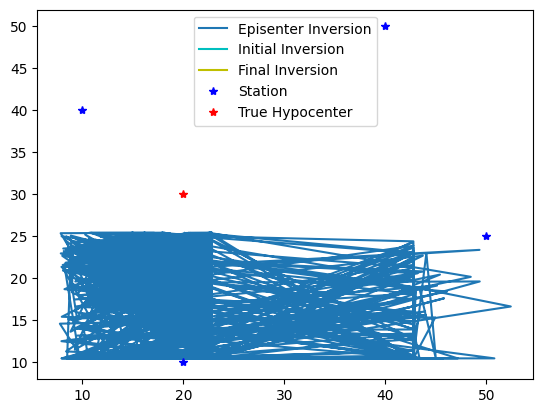

In [ ]:
# Simulated Annealing
import numpy as np
import matplotlib.pyplot as plt
import copy
from numpy.linalg import inv

Xtrue = 20
Ytrue = 30
Vavg = 4
tobs = []

Xsts = [20, 50, 40, 10]
Ysts = [10, 25, 50, 40]

# Generate data observasi
for i in range(len(Xsts)):
    noise = np.random.rand()
    r = np.sqrt((Xsts[i] - Xtrue)**2 + (Ysts[i] - Ytrue)**2)
    tobs.append((r / Vavg) + noise)

# Batas model
Xmin = 0
Ymin = 0
Xmax = 50
Ymax = 50

# Model awal
X = (Xmin + np.random.rand()) * (Xmax - Xmin)
Y = (Ymin + np.random.rand()) * (Ymax - Ymin)

# Hitung tcal awal
tcal = []
for i in range(len(Xsts)):
    tcal.append(np.sqrt((X - Xsts[i])**2 + (Y - Ysts[i])**2) / Vavg)

# Misfit awal
dt = []
E = []
for i in range(len(tcal)):
    dt.append(tobs[i] - tcal[i])
    E.append(dt[i] * dt[i])

T = copy.deepcopy(E)

k = 0
U = 0
Umax = 100
Lmax = 100
Amin = 100

HypoX = []
HypoY = []

while U < Umax:
    Lk = 0
    Ak = 0

    while Lk < Lmax and Ak < Amin:
        Urand = np.random.rand()
        ydX = np.sign(Urand - 0.5) * np.mean(T) * (
            ((1 + (1 / np.mean(T))) ** abs(2 * Urand - 1)) - 1
        )
        dX = ydX * (Xmax - Xmin) / 2

        if abs(dX) < 10:
            dX = (abs(dX) / dX) * 10

        Urand = np.random.rand()
        ydY = np.sign(Urand - 0.5) * np.mean(T) * (
            ((1 + (1 / np.mean(T))) ** abs(2 * Urand - 1)) - 1
        )
        dY = ydY * (Ymax - Ymin) / 2

        if abs(dY) < 10:
            dY = (abs(dY) / dY) * 10

        Urand = np.random.rand()

        X1 = X + dX
        Y1 = Y + dY

        # Hitung tcal baru
        for i in range(len(Xsts)):
            tcal[i] = np.sqrt((X1 - Xsts[i])**2 + (Y1 - Ysts[i])**2) / Vavg

        # Hitung error baru
        de = []
        for i in range(len(tcal)):
            de.append(tobs[i] - tcal[i])

        E1 = np.asmatrix(np.asmatrix(de) * np.asmatrix(de))
        dE = np.asmatrix(np.asmatrix(E1) - np.asmatrix(E))

        Lk = Lk + 1

        # Seleksi model
        if np.mean(dE) <= 0:
            HypoX.append(X1)
            HypoY.append(Y1)
            E = E1
            Ak = Ak + 1
        else:
            P = np.exp(-np.mean(dE) / np.mean(T))
            R = np.random.rand()

            if R < np.mean(P):
                HypoX.append(X1)
                HypoY.append(Y1)
                E = E1
                Ak = Ak + 1

    # Update temperatur
    if Ak == 0:
        U = U + 1
    else:
        U = 0

    T = np.asmatrix(np.asmatrix(T) * 0.99)
    k = k + 1

# Plot hasil
plt.plot(HypoX, HypoY, label='Episenter Inversion')
plt.plot(HypoX[0], HypoY[0], 'c', label='Initial Inversion')
plt.plot(HypoX[-1], HypoY[-1], 'y', label='Final Inversion')
plt.plot(Xsts, Ysts, '*b', label='Station')
plt.plot(Xtrue, Ytrue, '*r', label='True Hypocenter')

plt.legend()
plt.show()
